In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv("loan_approval_data.csv")

In [4]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [6]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_32404\3093607727.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [7]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [8]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [9]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le_target = LabelEncoder()
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le_target.fit_transform(df["Loan_Approved"])


In [10]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [11]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

       XGBoost Performance
  Accuracy  : 0.9250
  Precision : 0.8382
  Recall    : 0.9344
  F1 Score  : 0.8837
  ROC-AUC   : 0.9549
  CV F1     : 0.8995 ± 0.0211

              precision    recall  f1-score   support

Not Approved       0.97      0.92      0.94       139
    Approved       0.84      0.93      0.88        61

    accuracy                           0.93       200
   macro avg       0.90      0.93      0.91       200
weighted avg       0.93      0.93      0.93       200



d:\Credit_Wise\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


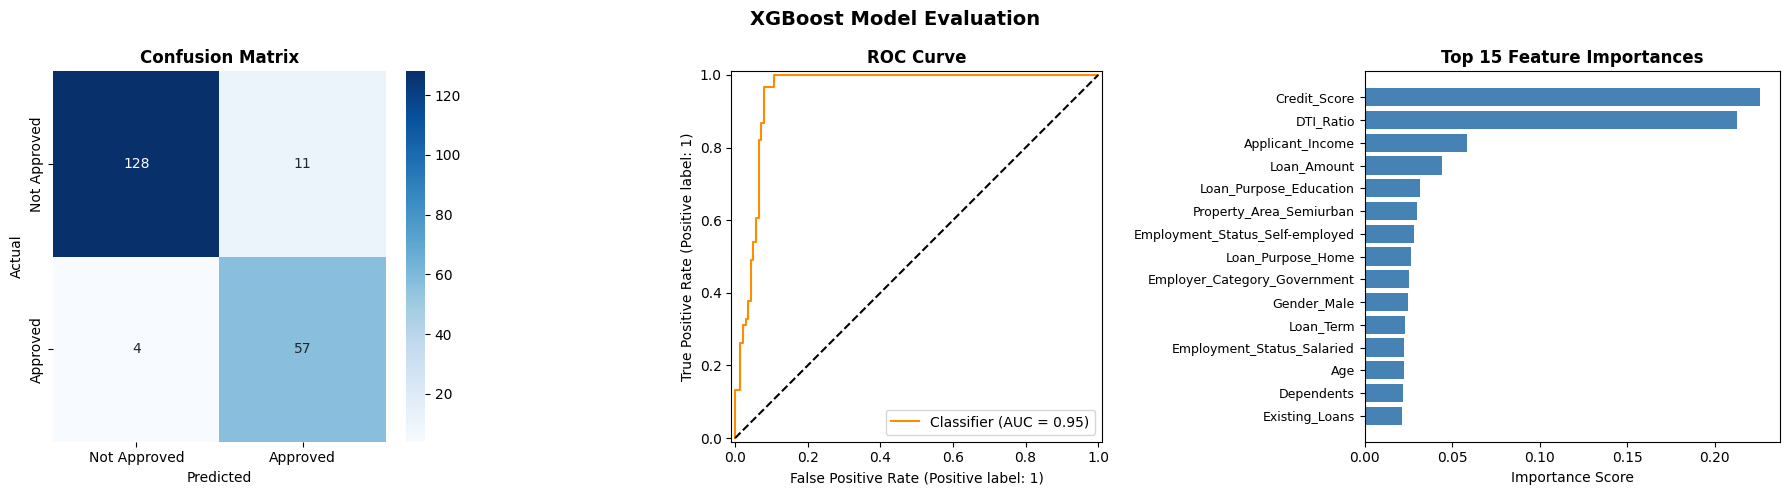

✅ Artifacts saved:
   artifacts/loan_model.pkl
   artifacts/scaler.pkl
   artifacts/ohe.pkl
   artifacts/label_encoder.pkl
   artifacts/feature_columns.json
   artifacts/model_metadata.json

📦 Metadata:
   model          : XGBClassifier
   accuracy       : 0.925
   precision      : 0.8382
   recall         : 0.9344
   f1             : 0.8837
   roc_auc        : 0.9549
   cv_f1_mean     : 0.8995
   cv_f1_std      : 0.0211
   n_features     : 28
   train_size     : 800
   test_size      : 200


: 

In [ ]:
# ── XGBoost Training & Saving ──
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import json
import os

# ── Train ──
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

# ── Evaluate ──
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='f1')

print("=" * 45)
print("       XGBoost Performance")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  CV F1     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not Approved', 'Approved']))

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color='darkorange')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve', fontweight='bold')

feat_imp   = xgb_model.feature_importances_
feat_names = X_train.columns.tolist()
top_idx    = np.argsort(feat_imp)[-15:]
axes[2].barh(range(15), feat_imp[top_idx], color='steelblue')
axes[2].set_yticks(range(15))
axes[2].set_yticklabels([feat_names[i] for i in top_idx], fontsize=9)
axes[2].set_title('Top 15 Feature Importances', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('XGBoost Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Save Artifacts ──
os.makedirs("artifacts", exist_ok=True)

joblib.dump(xgb_model, "artifacts/loan_model.pkl")   # overwrites previous model
joblib.dump(scaler,    "artifacts/scaler.pkl")
joblib.dump(ohe,       "artifacts/ohe.pkl")
joblib.dump(le,        "artifacts/label_encoder.pkl")

with open("artifacts/feature_columns.json", "w") as f:
    json.dump(X_train.columns.tolist(), f)

# Save model metadata for reference
metadata = {
    "model":       "XGBClassifier",
    "accuracy":    round(accuracy_score(y_test, y_pred), 4),
    "precision":   round(precision_score(y_test, y_pred), 4),
    "recall":      round(recall_score(y_test, y_pred), 4),
    "f1":          round(f1_score(y_test, y_pred), 4),
    "roc_auc":     round(roc_auc_score(y_test, y_prob), 4),
    "cv_f1_mean":  round(cv_scores.mean(), 4),
    "cv_f1_std":   round(cv_scores.std(), 4),
    "n_features":  len(X_train.columns),
    "train_size":  len(X_train),
    "test_size":   len(X_test),
}

with open("artifacts/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Artifacts saved:")
print("   artifacts/loan_model.pkl")
print("   artifacts/scaler.pkl")
print("   artifacts/ohe.pkl")
print("   artifacts/label_encoder.pkl")
print("   artifacts/feature_columns.json")
print("   artifacts/model_metadata.json")
print()
print("📦 Metadata:")
for k, v in metadata.items():
    print(f"   {k:<15}: {v}")